In [99]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *

Volumen V: 0.135+/-0.020 [ml] = (1.35+/-0.20)e-07 [m³]
Änderung Magnetfeld dB/dx: 41.8+/-1.4 [mT/mm = T/m]


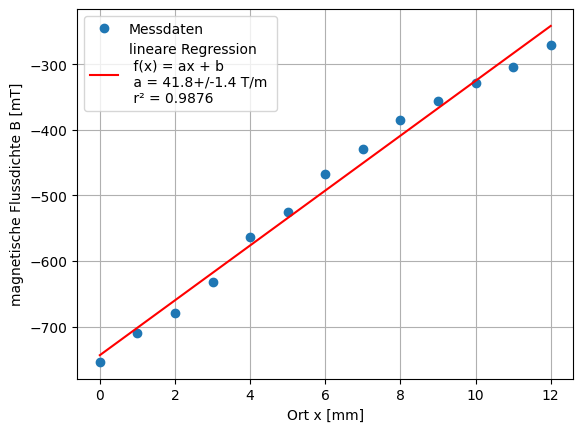

Kraft Fx: 0.00080+/-0.00010 [N]
Bx: -0.3560+/-0.0010 [T]
Suszeptibilität chi von Graphit: -0.00050+/-0.00010


In [108]:
# 1. magnetische suszeptibilität diamagnet (graphit) - Methode nach Faraday

#Parameter
d = 0.008           #[m]; Polschuhabstand, handfest ziehen; für Auswertung nicht notwendig aber für Versuchsaufbau
mu0 = 4 * np.pi * 10**(-7)    #[Vs/(Am)]; Konstante

V_ml = ufloat(0.135, 0.02)       #[ml]; entweder (0.135, 0.02) oder (0.35, 0.05) je nach verwendeter Probe
V = V_ml * 10**(-6)     #[m³]; volumen umgerechnet

print(f"Volumen V: {V_ml} [ml] = {V} [m³]")

#Messung B(x)
I = 10              #[A]; Betriebsstrom am Netzgerät einstellen

x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])        #[mm], langsam variieren
B = - np.array([754, 710, 679, 632, 563, 526, 468, 429, 385, 356, 329, 304, 270])       #[mT?], aufnehmen zum jeweiligen abstand mit CASSY
Bu = 1

reg = linregress(x, B)                     #linerare Regression zur Bestimmung der Änderung dBdx; NUR über linearen Teil!! INIDZES EINTRAGEN!!
dBdx = ufloat(reg.slope, reg.stderr)            #[mT/mm] = [T/m]; Änderung des Magnetfeldes

print(f"Änderung Magnetfeld dB/dx: {dBdx} [mT/mm = T/m]")

x_plot = np.linspace(0, 12, 200)
plt.figure()
plt.plot(x, B, 'o', label="Messdaten")
plt.plot(x_plot, x_plot*reg.slope +reg.intercept, '-r', label=f"lineare Regression \n f(x) = ax + b \n a = {dBdx} T/m \n r² = {reg.rvalue**2:.4f}")
plt.xlabel("Ort x [mm]")
plt.ylabel("magnetische Flussdichte B [mT]")
plt.legend()
plt.grid(True)
plt.show()

#Messung Fx
Fx = ufloat(0.8, 0.1) * 10**(-3)                 #[N]; Messsung mit CASSY im linearen Bereich; bin mir noch nicht sicher ob das ein array is oder nur 1 wert
Bx = ufloat(-356, 1) * 10**(-3)                #[T]; Wert zur Berechnung von chi, korresponiert zu Fx

print(f"Kraft Fx: {Fx} [N]")
print(f"Bx: {Bx} [T]")

#Berechnung Suszeptibilität
chi = (Fx * mu0) / (V * Bx * dBdx)          #Suszeptibilität, einheitslos

print(f"Suszeptibilität chi von Graphit: {chi}")

#vgl Literaturwert: chi_diamant = -2.2 * 10**(-5), chi_ghraphit= -4.5 * 10**(-4)



Querschnitt A: (2.97+/-0.05)e-05 [m²] = 29.7+/-0.5 [mm²]


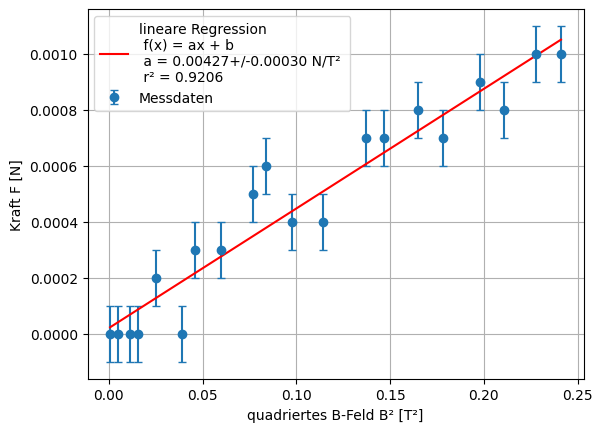

Suszeptibilität chi von Titan: 0.000362+/-0.000026


In [111]:
# 2. Suszeptibilität paramagnet (titan) - Methode nach Gouy

#Parameter
mu0 = 4 * np.pi * 10**(-7)    #[Vs/(Am)]; Konstante

d = ufloat(6.15, 0.05)/1000          #[m]; Durchmesser mit SChiebelehre messen
A = (d/2)**2 * np.pi    #[m²]; Querschnitt

print(f"Querschnitt A: {A} [m²] = {A*10**6} [mm²]")

#Messung F(B)
F = np.array([0, 0, 0, 0.3, 0.6, 0.4, 0.7, 0.7, 0.8, 1, 0, 0, 0.2, 0.3, 0.5, 0.4, 0.7, 0.8, 0.9, 1])/1000       #[N]; beides Messen mit CASSY; Messen für I = 0, 1, ..., 10 A und I = 0.5, 1.5, ..., 9.5 A
B = - np.array([72, 126, 197, 245, 290, 338, 383, 422, 459, 491, 27, 106, 159, 214, 277, 313, 370, 406, 445, 477])/1000       #[T]

F_u = 100 * 10**(-6)     #[N]; Auflösung/Unsicherheit Kraft: 10 mikro N

B2 = B**2

reg = linregress(B2, F)           #Änderung Kraft mit quadratischem B-Feld [N/T²]
a = ufloat(reg.slope, reg.stderr)

B2_plot = np.linspace(min(B2), max(B2), 200)
plt.figure()
plt.errorbar(B2, F, yerr=F_u, capsize=3, fmt='o', label="Messdaten")
plt.plot(B2_plot, B2_plot*reg.slope + reg.intercept, '-r', label=f"lineare Regression \n f(x) = ax + b \n a = {a} N/T² \n r² = {reg.rvalue**2:.4f}")
plt.xlabel("quadriertes B-Feld B² [T²]")
plt.ylabel("Kraft F [N]")
plt.legend()
plt.grid(True)
plt.show()

#Berechnung Suszeptibilität
chi = (a * 2 * mu0) / (A)       #Suszeptibilität, einheitslos

print(f"Suszeptibilität chi von Titan: {chi}")

#vgl Literaturwert: chi_titan = 1.8 * 10**(-4)


/home/paula/lp2/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: FutureWarning: AffineScalarFunc.__ge__() is deprecated. It will be removed in a future release.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


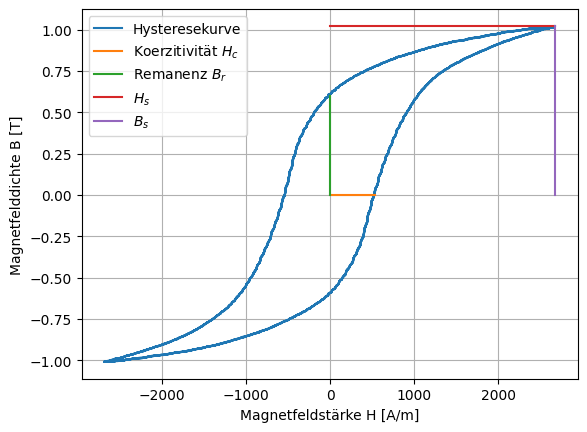

Koerzivität H_c: 509+/-15 [A/m]
Remanenz B_r: 0.612+/-0.018 [T]
H_s: (2.59+/-0.08)e+03 [A/m]
B_s: 1.026+/-0.031 [T]

Koerzivität H_c aus Plot/Datensatz: 539+/-16 [A/m]
Remanenz B_r aus Plot/Datensatz: 0.597+/-0.018 [T]
H_s aus Plot ermittelt: (2.67+/-0.08)e+03 [A/m]
B_s aus Plot ermittelt: 1.022+/-0.031 [T]


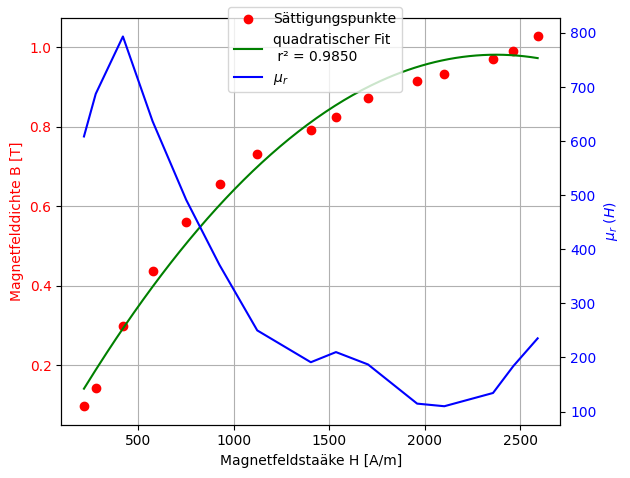

maximale relative Permeabilität mu_r: 793.4323450371018
Suszeptibilität chi: 792.4323450371018


In [ ]:
# 3. ferromagnetismus - Hystereseschleife

#Parameter
mu0 = 4 * np.pi * 10**(-7)     #[Vs/(Am)]; Konstante

n1 = 197                       #Zahl der Windungen Primärspule
L =  0.02                       #[m] Länge Primärspule
Rv = 46.4                       #[Ohm] Vorwiderstand der Primärwicklung

n2 = 788                       #Zahl der Windungen Sekundärspule
A =  2.02 * 10**(-4)                       #[m²] Querschnitt Sekundärspule
R = 70.7 * 10**3            #[kOhm --> Ohm] vom Integrationsglied gegeben
C = 10.6 * 10**(-6)         #[mikro F --> F] vom Intergrationsglied gegeben

#hystereseschleife plotten und Werte printen
df = pd.read_csv("T0000ALL.CSV", sep=",", decimal=".")
Ux = df["CH1"].to_numpy()                      #[V] Spannung x vom Oszilloskop
Uy = df["CH2"].to_numpy()                      #[V] Spannung y vom Oszilloskop
Uxu = Ux * 0.03                                #Unsicherheit vom Oszilloskop: 3%
Uyu = Uy * 0.03                                #Unsicherheit vom Oszilloskop: 3%

Ux_u = unp.uarray(Ux, np.abs(Uxu))             #values mit Unscherheiten machen
Uy_u = unp.uarray(Uy, np.abs(Uyu))             #values mit Unscherheiten machen

H = (n1 * Ux_u) / (L * Rv)                    #[A/m] Magnetfeld H
B = (R * C * Uy_u) / (n2 * A)                 #[T] B-Feld

Ux_Hc = ufloat(2.4, 2.4*0.03)                         #[V] Ux bei Hc; am Oszilloskop messen
Ux_Hs = ufloat(12.2, 12.2*0.03)                        #[V] Ux bei Hs; am Oszilloskop messen

Uy_Br = ufloat(130, 130*0.03) * 10**(-3)              #[V] Uy bei Br; am Oszilloskop messen
Uy_Bs = ufloat(218, 218*0.03) * 10**(-3)              #[V] Uy bei Bs; am Oszilloskop messen


Hc = (n1 * Ux_Hc) / (L * Rv)                           #[A/m] Koerzivität; diesen und folgende Werte am Oszilloskop messen 
Br = (R * C * Uy_Br) / (n2 * A)                            #[T] Remanenz

Hs = (n1 * Ux_Hs) / (L * Rv)                           #[A/m]; Parameter Sättigungspunkt
Bs = (R * C * Uy_Bs) / (n2 * A)                            #[T]


Hs_plot = np.max(H)                 #H_s Wert aus Plot der Kurve [A/m]
Bs_plot = np.max(B)                 #B_s Wert aus Plot der Kurve [T]

Hc_plot = H[376]                    #H_c Wert aus Plot/Datensatz ermittelt [A/m]
Br_plot = B[626]                    #B_r Wert aus Plot/Datensatz ermittelt [T]

def nom(x):                         #bin zu faul das jedes mal auszuschreiben deswegen gibts jetzt eine funktion dafür
    return unp.nominal_values(x)

plt.figure()
plt.plot(nom(H), nom(B), label="Hysteresekurve")
plt.plot([0, nom(Hc_plot)], [0, 0], '-', label=r"Koerzitivität $H_c$")
plt.plot([0, 0], [0, nom(Br_plot)], '-', label=r"Remanenz $B_r$")
plt.plot([0, nom(Hs_plot)], [nom(Bs_plot), nom(Bs_plot)], '-', label=r"$H_s$")
plt.plot([nom(Hs_plot), nom(Hs_plot)], [0, nom(Bs_plot)], '-', label=r"$B_s$")
plt.xlabel("Magnetfeldstärke H [A/m]")
plt.ylabel("magnetische Flussdichte B [T]")
plt.legend()
plt.grid(True)
plt.show()

print(f"Koerzivität H_c: {Hc} [A/m]")
print(f"Remanenz B_r: {Br} [T]")
print(f"H_s: {Hs} [A/m]")
print(f"B_s: {Bs} [T]")
print()

print(f"Koerzivität H_c aus Plot/Datensatz: {Hc_plot} [A/m]")
print(f"Remanenz B_r aus Plot/Datensatz: {Br_plot} [T]")
print(f"H_s aus Plot ermittelt: {Hs_plot} [A/m]")
print(f"B_s aus Plot ermittelt: {Bs_plot} [T]")


#ermitteln von Permeabilität mu_r und Suszeptibilität chi
#I = np.array([]) * 10**(-3)             #[mA --> A]; für mehrere Stromwerte messen (glaub die Werte brauchen wir gar nicht für die Auswertung)    

Ux = np.array([12.2, 11.6, 11.1, 9.9, 9.23, 8.02, 7.23, 6.61, 5.29, 4.36, 3.54, 2.71, 1.98, 1.31, 1.02])                      #[V], mit Oszillokop messen
Uy = np.array([218, 210, 206, 198, 194, 185, 175, 168, 155, 139, 119, 93, 63.6, 30.6, 20.6])/1000                      #[V], mit Oszilloskop messen
Uxu = unp.uarray(Ux, Ux*0.03)               #Unsicherheit vom Oszilloskop: 3%
Uyu = unp.uarray(Uy, Uy*0.03)               #Unsicherheit vom Oszilloskop: 3%

H_s = (n1 * Uxu) / (L * Rv)                      #[A/m] umgerechent aus Ux
B_s = (R * C * Uyu) / (n2 * A)                   #[T] umgerechnet aus Uy

H_s_nom = nom(H_s)                              #nominalwerte für plot und fit
B_s_nom = nom(B_s)                              #nominalwerte für plot und fit

fit = np.polyfit(nom(H_s), nom(B_s), 2)                   #quadratischer Fit
params = np.poly1d(fit)

ss_res = np.sum((B_s_nom - params(H_s_nom))**2)         #rechnunng für r² vom fit
ss_tot = np.sum((B_s_nom - np.mean(B_s_nom))**2)
r2 = 1 - ss_res/ss_tot

dBdH = np.gradient(B_s_nom, H_s_nom)                    #numerische Ableitung der Punkte = mu [Vs/(Am)]
mu_r = dBdH / mu0                               #einheitslos

mu_r_max = np.max(mu_r)                         #maximales mu_r
chi_max = mu_r_max - 1                          #chi bei mu_r_max


#plot und ergebnisse
H_plot = np.linspace(min(H_s_nom), max(H_s_nom), 200)

fig, ax1 = plt.subplots()

ax1.plot(H_s_nom, B_s_nom, 'o', color="red", label="Sättigungspunkte")
ax1.plot(H_plot, params(H_plot), '-', color="green", label=f"quadratischer Fit \n r² = {r2:.4f}")
ax1.set_xlabel("Magnetfeldstärke H [A/m]")
ax1.set_ylabel("magnetische Flussdichte B [T]", color="red")
ax1.tick_params(axis='y', labelcolor="red")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(H_s_nom, nom(mu_r), '-', color="blue", label=r"$\mu_r$")
ax2.set_ylabel(r"$\mu_r$ $(H)$", color="blue")
ax2.tick_params(axis='y', labelcolor="blue")

fig.legend(loc="upper center")
fig.tight_layout()
plt.show()

print(f"maximale relative Permeabilität mu_r: {mu_r_max}")
print(f"Suszeptibilität chi: {chi_max}")
